In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util_with_force_loss import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


In [2]:
# check if using GPU or CPU
# print("Using GPU:", jax.lib.xla_bridge.get_backend().platform == "gpu")

In [ ]:
from Energy_NN_architectures import *

K_init = jnp.array([0.005, 0.005])


# train_file = "../simulation_data_2D/slinky_2D_train_data_settled_start.npz"
# valid_file = "../simulation_data_2D/slinky_2D_train_data_settled_start.npz"

train_file = "../simulation_data_2D/slinky_2D_train_data_settled_start_top_bottom.npz"
valid_file = "../simulation_data_2D/slinky_2D_train_data_settled_start_top_bottom.npz"

In [4]:
from properties import SlinkyN3Properties

properties = SlinkyN3Properties(mass=0.3)

params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(42),
    hidden=(10,),
    which_case="ICNN",
    corr_factor=0.1,
    input_mode="invariant",
    zero_reference=True,
    activation="tanh",
    only_stretching_NN = True,
)

model_cls = DiagonalPlusEnergyNN


In [5]:
final_model, train_history, valid_history = train_model(
    properties=properties,
    model_cls=model_cls,
    params=params,
    train_file=train_file,
    valid_file=valid_file,
    n_epochs=500,
    lr=5e-2,
    max_dlambda=1e-2,
    iters=10,
    ls_steps=10,
    abs_tol=1e-4,
    rel_tol=1e-4,
    fail_on_nonconvergence=True,
    early_stop=True,
    hessian_reg_strength=1e-6,
    hessian_reg_probes=1,
    hessian_reg_seed=0,
    force_sign=1,
    force_components = [0,],
)

Epoch 000 | Train: 2.380e+00 | Valid: 3.219e-01
Epoch 100 | Train: 5.327e-02 | Valid: 5.231e-02
Epoch 200 | Train: 3.876e-02 | Valid: 3.768e-02
Epoch 300 | Train: 2.329e-02 | Valid: 2.300e-02
Epoch 400 | Train: 2.144e-02 | Valid: 2.120e-02


500


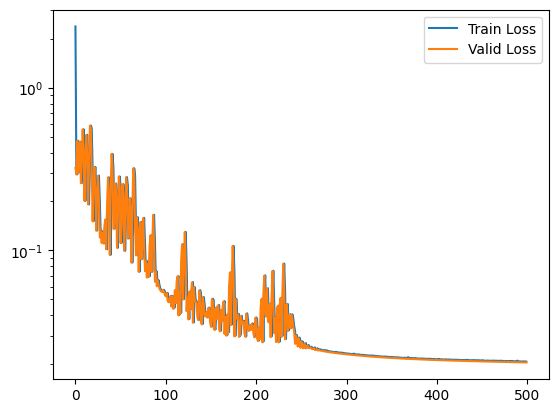

In [6]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [7]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

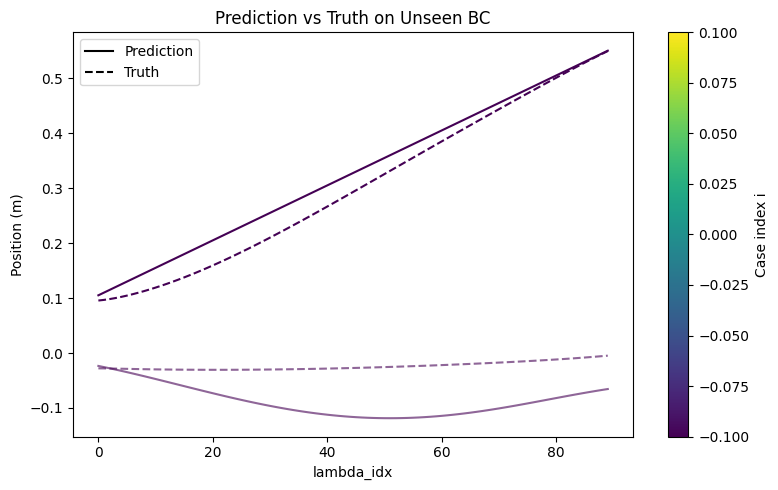

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

In [9]:
animate(pred[0])


In [10]:
animate(valid.qs[0])

In [11]:
base, aux = get_slinky(properties)
train_data = Dataset.load(train_file,
    force_key="F",
)

diag = print_force_match_diagnostics(
    final_model,
    base,
    aux,
    train_data,
    traj_idx=0,
    force_components=(0, 1, 2),
    force_sign=1.0,
)


Force MSE, same sign:     3.570061e-01
Force MSE, opposite sign: 1.896468e+01
Suggested force_sign:     +1


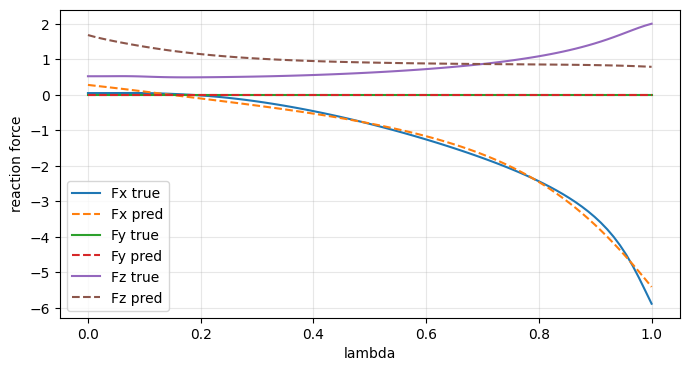

In [12]:
diag, ax = plot_force_match(
    final_model,
    base,
    aux,
    train_data,
    traj_idx=0,
    force_components=(0, 1, 2),
    force_sign=1.0,
    use_best_sign=True,
)
